In [ ]:
# ! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf


In [1]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [2]:
load_dotenv()

True

In [3]:
import os
from langchain_groq import ChatGroq

#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm=ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [4]:
loader = PyPDFLoader("Sushant Twayana Resume Updated.pdf")
docs = loader.load()

In [5]:
len(docs)

3

In [6]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [7]:
len(chunks)

9

In [9]:
# embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
from langchain_ollama import OllamaEmbeddings
embeddings = OllamaEmbeddings(model="gemma:2b")
vector_store = FAISS.from_documents(chunks, embeddings)

In [10]:
vector_store

In [11]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [15]:
retriever.invoke('What is the total experience of Sushant Twayana including interships?')[0]

Document(id='193f6267-c920-4ec2-a151-c7b6fdfd094a', metadata={'producer': 'Microsoft® Word for Microsoft 365', 'creator': 'Microsoft® Word for Microsoft 365', 'creationdate': '2025-12-29T09:58:38+05:45', 'author': 'Sushant Twayana', 'moddate': '2025-12-29T09:58:38+05:45', 'source': 'Sushant Twayana Resume Updated.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='Sushant Twayana    \nSallaghari, Bhaktapur    \nsushanttwayana1@gmail.com | +977 9861488545| Linked IN | Github | Blog \n    \nAI/ML Engineer specializing in production-grade LLM systems, MLOps, and scalable AI solutions. Expertise in \ndeploying enterprise applications using LangChain, LangGraph, RAG, Kubernetes, and AWS infrastructure with proven \ntrack record of optimizing model performance and reducing latency. \n \nPROFESSIONAL EXPERIENCE   \n    \nJunior AI/ML Engineer | V ANILLA TRANSTECHOR (July 2025 - Present) \nCore Technical Achievements: \n• Architected end-to-end multilingual speech processing p

In [12]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [16]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [17]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [18]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [19]:
tool_node = ToolNode(tools)

In [20]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

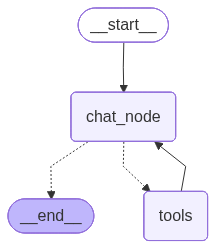

In [21]:
chatbot

In [22]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Can you summarize the resume of Sushant"
                )
            )
        ]
    }
)

In [23]:
print(result['messages'][-1].content)

**Sushant Twayana – AI/ML Engineer (Junior)**  
*Location:* Sallaghari, Bhaktapur, Nepal  
*Contact:* su​shanttwayana1@gmail.com • +977 9861488545 • LinkedIn • GitHub • Blog  

---

### Professional Snapshot
- **Current Role:** Junior AI/ML Engineer at **V ANILLA TRANSTECHOR** (July 2025 – Present)  
- **Core focus:** Building production‑grade LLM‑driven systems, MLOps pipelines, and scalable AI solutions for multilingual speech, OCR, and generative AI.  
- **Key achievements:**  
  - Designed an end‑to‑end multilingual speech pipeline (Whisper transcription + custom translation + Rasa intent classification) that lifted ASR accuracy and cut latency.  
  - Fine‑tuned Whisper models with LoRA for domain‑specific speech, benchmarked against AWS services.  
  - Contributing to OCR research for fintech documents.

---

### Highlight Projects (GitHub‑linked)

| Project | Tech Stack | Impact |
|---|---|---|
| **Scalable MNIST Classification Pipeline** | Kubeflow, KServe, Docker, CI/CD | Demon